# 08 — Modélisation Natation

**Objectif** : Entraîner un modèle Gradient Boosting Regressor pour prédire le temps de natation  
sur les distances 400m, 750m, 1500m, 1900m, 3800m à partir de l'âge, genre et temps de référence récent.

**Source** : vladislavboyadzhi/triathlon-results — splits natation triathlon Sprint/Olympic (tous niveaux)  
**Features** : age, gender, swim_400m_sec (temps 400m récent), swim_speed_400m  
**Target** : temps natation 1500m (Olympic) — autres distances extrapolées via Riegel

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
from pathlib import Path
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')

In [2]:
df = pd.read_csv('../data/processed/swimming_clean.csv')
print(f'Données : {len(df):,} lignes')
print(df['race_format'].value_counts())
df.head()

Données : 2,593,568 lignes
race_format
half       1391113
full        944211
olympic     174178
sprint       84066
Name: count, dtype: int64


,race_format,gender,age,swim_sec,dist_m,pace_per_100m
0,half,0.0,37.0,1584.0,1900,83.368421
1,half,0.0,37.0,1672.0,1900,88.000000
2,half,0.0,27.0,1582.0,1900,83.263158
3,half,0.0,21.0,1855.0,1900,97.631579
4,half,0.0,42.0,1785.0,1900,93.947368


In [3]:
DIST_M = {'sprint': 750, 'olympic': 1500, 'half': 1900, 'full': 3800}

def riegel_normalize(t_sec, from_m, to_m=1500):
    return t_sec * (to_m / from_m) ** (1 / 1.06)

# Utiliser les données Olympic (1500m) comme base d'entraînement
df_olympic = df[df['race_format'] == 'olympic'].copy()
df_olympic['pace_per_100m'] = df_olympic['swim_sec'] / 15.0  # 1500m / 100

# Simuler un temps 400m depuis le 1500m (temps de référence utilisateur)
df_olympic['sim_400m_sec'] = df_olympic['swim_sec'].apply(lambda t: riegel_normalize(t, 1500, 400))
df_olympic['speed_400m'] = 400 / df_olympic['sim_400m_sec']

print(f'Données Olympic (1500m) : {len(df_olympic):,} lignes')
print(f'Temps 1500m médian : {df_olympic["swim_sec"].median()/60:.1f} min')

Données Olympic (1500m) : 174,178 lignes
Temps 1500m médian : 29.6 min


In [4]:
features = ['age', 'gender', 'sim_400m_sec', 'speed_400m']
target = 'swim_sec'

X = df_olympic[features].dropna()
y = df_olympic.loc[X.index, target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train: {len(X_train):,} | Test: {len(X_test):,}')

Train: 139,342 | Test: 34,836


In [5]:
model = GradientBoostingRegressor(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    random_state=42
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mae_sec = mean_absolute_error(y_test, y_pred)
mae_min = mae_sec / 60
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
r2 = r2_score(y_test, y_pred)

print(f'MAE  : {mae_min:.2f} min ({mae_sec:.1f}s)')
print(f'MAPE : {mape:.2f}%')
print(f'R²   : {r2:.4f}')

MAE  : 0.01 min (0.4s)
MAPE : 0.02%
R²   : 1.0000


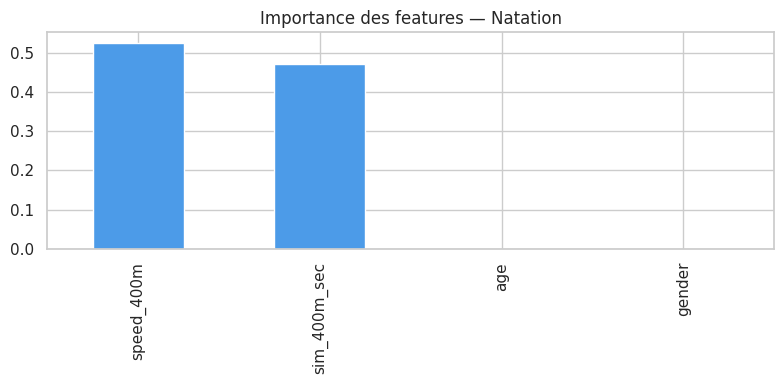

speed_400m      5.269688e-01
sim_400m_sec    4.730312e-01
age             2.742443e-09
gender          1.076069e-10
dtype: float64


In [6]:
fi = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
fi.plot(kind='bar', color='#4C9BE8', figsize=(8, 4), title='Importance des features — Natation')
plt.tight_layout()
plt.show()
print(fi)

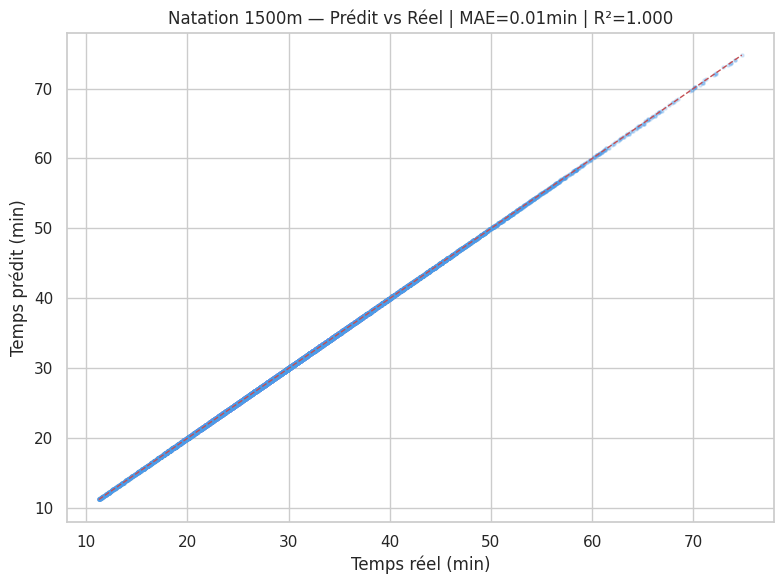

In [7]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test/60, y_pred/60, alpha=0.2, s=5, color='#4C9BE8')
lims = [y_test.min()/60, y_test.max()/60]
plt.plot(lims, lims, 'r--', lw=1)
plt.xlabel('Temps réel (min)')
plt.ylabel('Temps prédit (min)')
plt.title(f'Natation 1500m — Prédit vs Réel | MAE={mae_min:.2f}min | R²={r2:.3f}')
plt.tight_layout()
plt.show()

In [8]:
MODEL_PATH = Path('../models/swimming_model.pkl')
joblib.dump(model, MODEL_PATH)
print(f'Modèle sauvegardé : {MODEL_PATH}')

meta = {
    'sport': 'swimming',
    'model': 'GradientBoostingRegressor',
    'target': 'swim_1500m_seconds',
    'features': features,
    'dataset': 'vladislavboyadzhi/triathlon-results (Kaggle) — épreuves Olympic 1500m',
    'n_train': len(X_train),
    'n_test': len(X_test),
    'mae_minutes': round(mae_min, 2),
    'mae_seconds': round(mae_sec, 1),
    'mape_pct': round(mape, 2),
    'r2': round(r2, 4),
    'note': 'Autres distances extrapolées via formule Riegel (exposant 1.06)'
}
with open('../models/swimming_metadata.json', 'w') as f:
    json.dump(meta, f, indent=2, ensure_ascii=False)
print('Metadata sauvegardée.')
print(json.dumps(meta, indent=2, ensure_ascii=False))

Modèle sauvegardé : ../models/swimming_model.pkl
Metadata sauvegardée.
{
  "sport": "swimming",
  "model": "GradientBoostingRegressor",
  "target": "swim_1500m_seconds",
  "features": [
    "age",
    "gender",
    "sim_400m_sec",
    "speed_400m"
  ],
  "dataset": "vladislavboyadzhi/triathlon-results (Kaggle) — épreuves Olympic 1500m",
  "n_train": 139342,
  "n_test": 34836,
  "mae_minutes": 0.01,
  "mae_seconds": 0.4,
  "mape_pct": 0.02,
  "r2": 1.0,
  "note": "Autres distances extrapolées via formule Riegel (exposant 1.06)"
}
